In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from typing import Iterable
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm

* read in the **AN**notated **Y**east **I**nteractome as pd.DataFrame object

In [2]:
DATA_DIR  = "../../flatten/processed-data"
DATA_FILE = f"{DATA_DIR}/20251023-s288c-annotated-PPI-net.pkl"
nodes     = pd.read_pickle(DATA_FILE)

* define hubs based on a degree centrality quantile threshold

In [8]:
# determine threshold for hubs based on quantile cutoff for degree centrality
cut          = 0.10
threshold    = nodes["degree_centrality"].quantile(1 - cut)

# add a boolean hub column: True if degree_centrality >= threshold, else False
nodes["hub"] = nodes["degree_centrality"] >= threshold
n_hubs       = nodes["hub"].sum()
n_nothubs    = (~nodes["hub"]).sum()

print(f"Threshold for defining a hub in MS data is {threshold:.5f}; there are {n_hubs} hubs and {n_nothubs} non hubs")

# filter to nodes with a UniProtKB-AC value, meaning their UniProt annotations could be extracted
nodes        = nodes[~nodes["UniProtKB-AC"].isna()]

Threshold for defining a hub in MS data is 0.01172; there are 400 hubs and 3485 non hubs


### Association of hubs with phosphorylation (UniProt PTMs only)

This is our contingency table:



<Figure size 640x480 with 0 Axes>

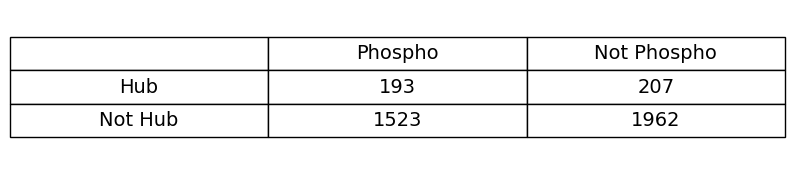

The odds ratio is: 1.20
The p-value is   : 0.0889070


In [13]:
# Boolean: "phospho" appears anywhere in parsed_PTMs (case-insensitive)
has_phospho_text = nodes["parsed_PTMs"].str.contains(
    "phospho", case=False, na=False
)

# add column to nodes
nodes["phosphorylated"] = has_phospho_text

# compute the values of {a, b, c, d} and construct the contingency table
a = len(nodes[(nodes["hub"] == True ) & (nodes["phosphorylated"] == True )])
b = len(nodes[(nodes["hub"] == True ) & (nodes["phosphorylated"] == False)])
c = len(nodes[(nodes["hub"] == False) & (nodes["phosphorylated"] == True )])
d = len(nodes[(nodes["hub"] == False) & (nodes["phosphorylated"] == False)])

# put values into a new format to enable a nice print statement & analysis
contingency_table = pd.DataFrame({"Phospho"    : [a, c], 
                                  "Not Phospho": [b, d]},
                                  index = ["Hub", "Not Hub"])

# print the output
print ("This is our contingency table:\n")

# create a table from our contingency_table using matplotlib
plt.clf()
fig, ax    = plt.subplots(figsize = (5, 2))
ax.axis("tight")
ax.axis("off")
cell_text  = contingency_table.reset_index().values.tolist()
col_labels = [""] + contingency_table.columns.tolist()
table      = ax.table(cellText=cell_text, colLabels=col_labels, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(14)  
table.scale(2, 2)  
plt.show()

# use the fisher_exact function from scipy.stats to compute the odds ratio and p-value
odds_ratio, fisher_p_value = fisher_exact(contingency_table, alternative = "two-sided")

# print the results of this analysis
print ("The odds ratio is:", "%.2f" %odds_ratio)
print ("The p-value is   :", "%.7f" %fisher_p_value)

* when considering only the UniProt consensus annotations, there is a weak positive association between hubs and phosphorylation, but it is not statistically significant

### Association of hubs with phosphorylation (UniProt PTMs + ProteomeXchange Gold annotations)
* In this analysis, we will consider UniProt consensus annotations plus the gold standard MS annotations from ProteomeXchange

This is our contingency table:



<Figure size 640x480 with 0 Axes>

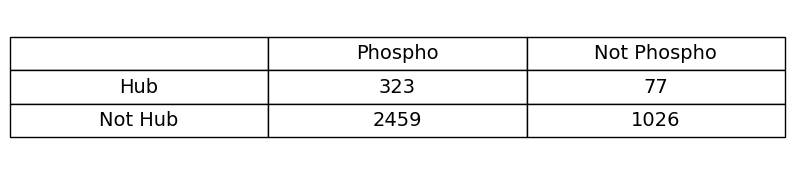

The odds ratio is: 1.75
The p-value is   : 0.0000108


In [19]:
has_phospho_flag = (nodes["ptm_gold"].notna())

has_phospho_text = nodes["parsed_PTMs"].str.contains(
    "phospho", case=False, na=False
)

# combine both criteria
nodes["phosphorylated"] = has_phospho_flag | has_phospho_text

# compute the values of {a, b, c, d} and construct the contingency table
a = len(nodes[(nodes["hub"] == True ) & (nodes["phosphorylated"] == True )])
b = len(nodes[(nodes["hub"] == True ) & (nodes["phosphorylated"] == False)])
c = len(nodes[(nodes["hub"] == False) & (nodes["phosphorylated"] == True )])
d = len(nodes[(nodes["hub"] == False) & (nodes["phosphorylated"] == False)])

# put values into a new format to enable a nice print statement & analysis
contingency_table = pd.DataFrame({"Phospho"    : [a, c], 
                                  "Not Phospho": [b, d]},
                                 index = ["Hub", "Not Hub"])

# print the output
print ("This is our contingency table:\n")

# create a table from our contingency_table using matplotlib
plt.clf()
fig, ax    = plt.subplots(figsize = (5, 2))
ax.axis("tight")
ax.axis("off")
cell_text  = contingency_table.reset_index().values.tolist()
col_labels = [""] + contingency_table.columns.tolist()
table      = ax.table(cellText=cell_text, colLabels=col_labels, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(14)  
table.scale(2, 2)  
plt.show()

# use the fisher_exact function from scipy.stats to compute the odds ratio and p-value
odds_ratio, fisher_p_value = fisher_exact(contingency_table, alternative = "two-sided")

# print the results of this analysis
print ("The odds ratio is:", "%.2f" %odds_ratio)
print ("The p-value is   :", "%.7f" %fisher_p_value)

### Check to see if essentiality is a confounding factor
* essential proteins have been subjected to a disproportionate amount of study and may be more likely to 

In [17]:
data1 = nodes[["phosphorylated", "hub", "essential"]].copy()

recode_map = {True: 1, False: 0}

data1["phosphorylated"] = data1["phosphorylated"].map(recode_map)
data1["hub"] = data1["hub"].map(recode_map)
data1["intercept"] = 1

# feature only
X1 = data1[["intercept", "phosphorylated"]]

# X1 feature and the confounder
X2 = data1[["intercept", "phosphorylated", "essential"]]

y = data1["hub"]

In [18]:
model1  = sm.Logit(y, X1)
result1 = model1.fit(disp = 0)

# print a summary of result1
print ("\nResults when confounding factor IS NOT included:\n")

# get a summary of the results
odds_ratios = pd.DataFrame({"Coefficient": result1.params,
                            "OR"         : np.exp(result1.params),  
                            "Lower CI"   : np.exp(result1.conf_int()[0]),  
                            "Upper CI"   : np.exp(result1.conf_int()[1]),
                            "p-value"    : result1.pvalues}).drop(index="intercept", errors="ignore")

# print the odds ratio
print (odds_ratios.round(3), "\n")

# model2 includes the confounder
model2 = sm.Logit(y, X2)
result2 = model2.fit(disp = 0)

# print a summary of result2
print ("\nResults when confounding factor IS included:\n")

# get a summary of the results
odds_ratios = pd.DataFrame({"Coefficient": result2.params,
                            "OR"         : np.exp(result2.params),  
                            "Lower CI"   : np.exp(result2.conf_int()[0]),  
                            "Upper CI"   : np.exp(result2.conf_int()[1]),
                            "p-value"    : result2.pvalues}).drop(index="intercept", errors="ignore")

# print the odds ratio
print (odds_ratios.round(3), "\n")


Results when confounding factor IS NOT included:

                Coefficient    OR  Lower CI  Upper CI  p-value
phosphorylated         0.56  1.75     1.351     2.268      0.0 


Results when confounding factor IS included:

                Coefficient     OR  Lower CI  Upper CI  p-value
phosphorylated        0.505  1.657     1.276     2.151      0.0
essential             0.858  2.358     1.906     2.918      0.0 

